We are solving:

$$
f(x) = \frac{1}{2} x^T A x
$$

- \(A\) is very ill-conditioned (eigenvalues range from 1 to \(10^6\))  
- Dimension = 500 (high-dimensional problem)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 500

In [2]:
U, _ = np.linalg.qr(np.random.randn(n, n))
eigs = np.linspace(1, 1e6, n)
A = U @ np.diag(eigs) @ U.T

In [3]:
def f(x):
    return 0.5 * x.T @ A @ x

def grad(x):
    return A @ x

x0 = np.random.randn(n)

In [4]:
def line_search(x, d):
    alpha = 1.0
    rho = 0.5
    c = 1e-4
    
    fx = f(x)
    g = grad(x)
    
    while f(x + alpha * d) > fx + c * alpha * (g @ d):
        alpha *= rho
    
    return alpha

In [5]:
def bfgs(x0, max_iter=50):
    n = len(x0)
    H = np.eye(n)
    x = x0.copy()
    
    hist = []

    for _ in range(max_iter):
        g = grad(x)
        d = -H @ g
        
        alpha = line_search(x, d)
        x_new = x + alpha * d
        
        g_new = grad(x_new)
        
        s = x_new - x
        y = g_new - g
        
        if y @ s <= 1e-10:
            break
        
        rho = 1.0 / (y @ s)
        I = np.eye(n)
        
        H = (I - rho*np.outer(s,y)) @ H @ (I - rho*np.outer(y,s)) + rho*np.outer(s,s)
        
        x = x_new
        hist.append(np.linalg.norm(g))
        
    return x, hist

In [6]:
def two_loop(g, S, Y):
    q = g.copy()
    alpha = []
    rho = []

    for i in reversed(range(len(S))):
        s, y = S[i], Y[i]
        r = 1.0 / (y @ s)
        rho.append(r)
        a = r * (s @ q)
        alpha.append(a)
        q = q - a * y

    if len(S) > 0:
        s, y = S[-1], Y[-1]
        gamma = (s @ y) / (y @ y)
    else:
        gamma = 1.0

    r = gamma * q

    for i in range(len(S)):
        s, y = S[i], Y[i]
        r_i = rho[len(S)-1-i]
        a_i = alpha[len(S)-1-i]
        beta = r_i * (y @ r)
        r = r + s * (a_i - beta)

    return -r

In [8]:
def lbfgs(x0, m=10, max_iter=50):
    x = x0.copy()
    
    S, Y = [], []
    hist = []

    for _ in range(max_iter):
        g = grad(x)
        d = two_loop(g, S, Y)
        
        alpha = line_search(x, d)
        x_new = x + alpha * d
        
        g_new = grad(x_new)
        
        s = x_new - x
        y = g_new - g
        
        if y @ s > 1e-10:
            S.append(s)
            Y.append(y)
            
            if len(S) > m:
                S.pop(0)
                Y.pop(0)
        
        x = x_new
        hist.append(np.linalg.norm(g))
    
    
    return x, hist

In [9]:
xb, hist_bfgs = bfgs(x0)
xl, hist_lbfgs = lbfgs(x0)

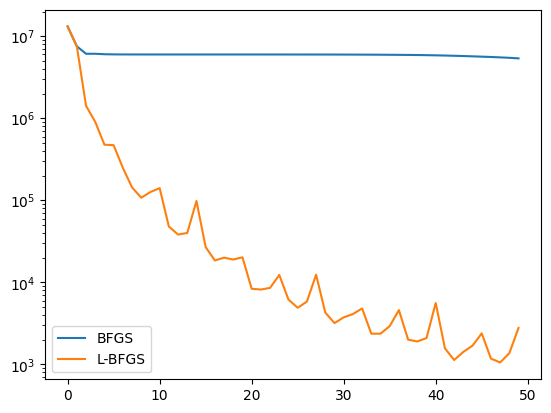

In [10]:
plt.plot(hist_bfgs, label="BFGS")
plt.plot(hist_lbfgs, label="L-BFGS")
plt.yscale("log")
plt.legend()
plt.show()

In [11]:
print("Final grad norm (BFGS):", hist_bfgs[-1])
print("Final grad norm (L-BFGS):", hist_lbfgs[-1])

Final grad norm (BFGS): 5376713.411080724
Final grad norm (L-BFGS): 2784.3548132298197


## Observation: BFGS vs L-BFGS

- Y-axis: $\|\nabla f(x_k)\|$ (log scale)  
- X-axis: Iterations  

---

### What we observe

- BFGS:
  - Rapid initial decrease  
  - Then plateaus around $10^6$  

- L-BFGS:
  - Slower initial decrease  
  - Continues reducing steadily  
  - Reaches around $10^3$  

---

### Interpretation

- BFGS:
  - Uses full curvature approximation  
  - In high dimensions, accumulated curvature becomes inaccurate  
  - Leads to poor search directions and stagnation  

- L-BFGS:
  - Uses limited recent curvature information  
  - Avoids accumulation of errors  
  - Produces more stable descent directions  

---

### Conclusion

Limited-memory updates provide better stability and convergence in high-dimensional, ill-conditioned problems compared to full-memory BFGS.